In [1]:
import numpy as np
import pandas as pd
from scipy import constants
from scipy import special as sp 
from scipy.interpolate import interp1d
import os
import pickle
import subprocess

# Encontrando as frequencias para os modos TM $_{0np}$

In [9]:
d = 0.276
R = 0.5202

f0np = lambda n, p: ((constants.c * np.sqrt((sp.jn_zeros(0, n)[n-1]/R)**2 + ((p * constants.pi)/d)**2)) / (2*constants.pi)) *1e-6 

In [10]:
def pairs(i, j):
    pares = []
    for x in range(1, i+1):
        for y in range(0, j+1):
            pares.append((x, y))
    return pares
pares = pairs(4, 4)

In [4]:
pares

[(1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4),
 (4, 0),
 (4, 1),
 (4, 2),
 (4, 3),
 (4, 4)]

In [5]:
modos = []
for f in pares:
    modos.append({"Modo":f, "Freq": f0np(f[0], f[1])})
modos

[{'Modo': (1, 0), 'Freq': np.float64(220.5738712710689)},
 {'Modo': (1, 1), 'Freq': np.float64(586.1850545064739)},
 {'Modo': (1, 2), 'Freq': np.float64(1108.3741130342735)},
 {'Modo': (1, 3), 'Freq': np.float64(1644.1695781277463)},
 {'Modo': (1, 4), 'Freq': np.float64(2183.578301713848)},
 {'Modo': (2, 0), 'Freq': np.float64(506.3090728589849)},
 {'Modo': (2, 1), 'Freq': np.float64(742.5018267308012)},
 {'Modo': (2, 2), 'Freq': np.float64(1198.411122702193)},
 {'Modo': (2, 3), 'Freq': np.float64(1706.1622567073127)},
 {'Modo': (2, 4), 'Freq': np.float64(2230.6300106219664)},
 {'Modo': (3, 0), 'Freq': np.float64(793.7316952445514)},
 {'Modo': (3, 1), 'Freq': np.float64(961.7536532163739)},
 {'Modo': (3, 2), 'Freq': np.float64(1345.306785009574)},
 {'Modo': (3, 3), 'Freq': np.float64(1812.3605527016564)},
 {'Modo': (3, 4), 'Freq': np.float64(2312.870807257469)},
 {'Modo': (4, 0), 'Freq': np.float64(1081.535577961678)},
 {'Modo': (4, 1), 'Freq': np.float64(1210.23935311828)},
 {'Modo': 

In [6]:
len(modos)

20

## Encontrando os valores para as permeabilidade magnética imaginária e real 

In [11]:
freq = [0.15625, 0.2695035460992908, 0.5106382978723404, 0.75177304964539, 0.9645390070921985, 1.2198581560283688, 1.4468085106382977, 1.7304964539007093, 2, 2.25531914893617, 2.49645390070922, 2.75177304964539, 3.00709219858156, 3.24822695035461, 3.50354609929078]
mu_real = [8, 2.8753623188405797, 0.6260869565217391, 0.02318840579710102, -0.23188405797101375, -0.41739130434782545, -0.5565217391304351, -0.649275362318841, -0.6724637681159429, -0.695652173913043, -0.6724637681159429, -0.649275362318841, -0.579710144927537, -0.5565217391304351, -0.5101449275362313]
mu_imag = [65.517241379, 39.56043956043956, 21.61172161172162, 14.285714285714292, 10.989010989010993, 8.974358974358978, 7.509157509157518, 6.227106227106233, 5.128205128205138, 4.395604395604408, 3.846153846153854, 3.296703296703299, 2.930402930402934, 2.747252747252759, 2.564102564102569]



In [12]:
inter = interp1d(freq, mu_real)
inter2 = interp1d(freq, mu_imag)

## Executando as simulações

In [13]:
def gera_arquivo(boundarie, freq, mode):
    wb = ""
    if boundarie:
        wb = "PE"
    else:
        wb = "PM"
    code = f"""
    {freq} {wb}
    $reg kprob=1,
    kmethod=1,
    dx=0.1,
    dy=0.1,
    freq={freq},
    beta=1,
    norm=1,
    clength=13.8
    ezero=3260869.57,
    ezerot=3260869.57
    rmass=0.511,
    nbsup = 1,
    nbslo = 0,
    nbsrt = 1,
    nbslf = {boundarie},
    zctr=0$
    $po x=0, y=0$
    $po x=23.8, y=0$  
    $po x=23.8, y=3.5$
    $po x=13.8, y=3.5$
    $po x=11.3, y=3.5$
    $po nt=5, x0=11.3, y0=4.5, x=-0.573576436351046, y=0.8191520442889918, radius=1$
    $po x=13.458861149080837, y=7.232425439295934$
    $po nt=2, x0=13.0, y0=7.887747074727128, x=0.8, y=0, radius=0.8$
    $po x=13.8, y=34.0$
    $po nt=2, x0=13.9, y0=34.0, x=0, y=0.1, radius=0.1$
    $po x=17.8, y=34.1$
    $po x=17.8, y=35.1$
    $po x=13.9, y=35.1$
    $po nt=2, x0=13.9, y0=35.2, x=-0.1, y=0, radius=0.1$
    $po x=13.8, y=41.02$
    $po nt=2, x0=2.8000000000000007, y0=41.02, x=0, y=11, radius=11$
    $po x=0, y=52.02$
    $po x=0, y=0$
    $reg mat=2 $
    $po x=15.8,y=34.1$
    $po x=17.8,y=34.1$
    $po x=17.8,y=33.1$
    $po x=15.8,y=33.1$
    $po x=15.8,y=34.1$
    &mt epsilon = 10.6, mu = {inter(freq*1E-3)} {inter2(freq*1E-3)}&
    """
    #with open(f"{mode} {wb}.af", "wt") as f:
    #    f.write(code)
    return f"{mode} {wb}"


In [14]:
nomes = []
for modo in modos:
    
    if modo["Modo"][1] != 0:
        nome = gera_arquivo(0, modo["Freq"], f"{modo["Modo"]}")
        nomes.append(nome)
        nome = gera_arquivo(1, modo["Freq"], f"{modo["Modo"]}")
    else:
        nome = gera_arquivo(1, modo["Freq"], f"{modo["Modo"]}")
    nomes.append(nome)

In [51]:
nomes

['(1, 0) PE',
 '(1, 1) PM',
 '(1, 1) PE',
 '(1, 2) PM',
 '(1, 2) PE',
 '(1, 3) PM',
 '(1, 3) PE',
 '(1, 4) PM',
 '(1, 4) PE',
 '(2, 0) PE',
 '(2, 1) PM',
 '(2, 1) PE',
 '(2, 2) PM',
 '(2, 2) PE',
 '(2, 3) PM',
 '(2, 3) PE',
 '(2, 4) PM',
 '(2, 4) PE',
 '(3, 0) PE',
 '(3, 1) PM',
 '(3, 1) PE',
 '(3, 2) PM',
 '(3, 2) PE',
 '(3, 3) PM',
 '(3, 3) PE',
 '(3, 4) PM',
 '(3, 4) PE',
 '(4, 0) PE',
 '(4, 1) PM',
 '(4, 1) PE',
 '(4, 2) PM',
 '(4, 2) PE',
 '(4, 3) PM',
 '(4, 3) PE',
 '(4, 4) PM',
 '(4, 4) PE']

In [16]:
OUTPUT = []

In [17]:
resultados = {"Modes": [], "Ressonant Frequencies": [], "Q": [], "r/Q": []}
for nome in nomes:
    resultados["Modes"].append(nome)
    #subprocess.run([r"C:\LANL\AUTOMESH.EXE", f"{nome}.af"], check=True)
    #subprocess.run([r"C:\LANL\CFISH.EXE", f"{nome}.T35"], check=True)
    #subprocess.run([r"C:\LANL\SFO.EXE", f"{nome}.T35"], check=True)
    with open("OUTFIS.TXT", "r") as o:
        lines = o.readlines()
        for line in lines:
            if "Solution converged at the start" in line:
                OUTPUT.append(f"{nome} : Success")
            elif "Solution terminated at the maximum" in line:
                OUTPUT.append(f"{nome} : Failure")
        o.close()
    with open(f"{nome}.SFO", "r") as f:
        lines = f.readlines()
        readed = False
        for line in lines:
            if "Frequency for T integrals" in line:
                resultados["Ressonant Frequencies"].append(float(line.split()[5]))
                readed = True
                continue
            elif not readed:
                continue
            if "Shunt impedance" in line:
                resultados["Q"].append(float(line.split()[2]))
                continue
            if "r/Q" in line:
                resultados["r/Q"].append(float(line.split()[2]))
                break

    

    

In [18]:
OUTPUT

['(1, 0) PE : Success',
 '(1, 1) PM : Success',
 '(1, 1) PE : Success',
 '(1, 2) PM : Success',
 '(1, 2) PE : Success',
 '(1, 3) PM : Success',
 '(1, 3) PE : Success',
 '(1, 4) PM : Success',
 '(1, 4) PE : Success',
 '(2, 0) PE : Success',
 '(2, 1) PM : Success',
 '(2, 1) PE : Success',
 '(2, 2) PM : Success',
 '(2, 2) PE : Success',
 '(2, 3) PM : Success',
 '(2, 3) PE : Success',
 '(2, 4) PM : Success',
 '(2, 4) PE : Success',
 '(3, 0) PE : Success',
 '(3, 1) PM : Success',
 '(3, 1) PE : Success',
 '(3, 2) PM : Success',
 '(3, 2) PE : Success',
 '(3, 3) PM : Success',
 '(3, 3) PE : Success',
 '(3, 4) PM : Success',
 '(3, 4) PE : Success',
 '(4, 0) PE : Success',
 '(4, 1) PM : Success',
 '(4, 1) PE : Success',
 '(4, 2) PM : Success',
 '(4, 2) PE : Success',
 '(4, 3) PM : Success',
 '(4, 3) PE : Success',
 '(4, 4) PM : Success',
 '(4, 4) PE : Success']

In [19]:
resultados

{'Modes': ['(1, 0) PE',
  '(1, 1) PM',
  '(1, 1) PE',
  '(1, 2) PM',
  '(1, 2) PE',
  '(1, 3) PM',
  '(1, 3) PE',
  '(1, 4) PM',
  '(1, 4) PE',
  '(2, 0) PE',
  '(2, 1) PM',
  '(2, 1) PE',
  '(2, 2) PM',
  '(2, 2) PE',
  '(2, 3) PM',
  '(2, 3) PE',
  '(2, 4) PM',
  '(2, 4) PE',
  '(3, 0) PE',
  '(3, 1) PM',
  '(3, 1) PE',
  '(3, 2) PM',
  '(3, 2) PE',
  '(3, 3) PM',
  '(3, 3) PE',
  '(3, 4) PM',
  '(3, 4) PE',
  '(4, 0) PE',
  '(4, 1) PM',
  '(4, 1) PE',
  '(4, 2) PM',
  '(4, 2) PE',
  '(4, 3) PM',
  '(4, 3) PE',
  '(4, 4) PM',
  '(4, 4) PE'],
 'Ressonant Frequencies': [238.0845184,
  622.5269855,
  508.7871549,
  767.7089119,
  1062.1289011,
  1665.5318654,
  1817.2364927,
  2288.050802,
  2197.8375872,
  508.7871568,
  767.9325905,
  790.5885489,
  1238.4641966,
  1229.1091673,
  1730.6373362,
  1817.2182814,
  2255.9234929,
  2259.5124251,
  790.3354224,
  986.7857146,
  1144.8939117,
  1495.5110055,
  1356.7134769,
  1730.4229246,
  1817.1890803,
  2308.406357,
  2260.5252004,
  10

## Lendo os arquivos de simulação

In [20]:
index = np.arange(0, 36)

In [21]:
dataframe = pd.DataFrame(resultados)
dataframe = dataframe.sort_values("Ressonant Frequencies")

In [22]:
dataframe.index = index

In [23]:
v1 = 0
for i in index:
    if dataframe["Ressonant Frequencies"][i] - v1 < 1:
        dataframe = dataframe.drop(i)
    else:
        v1 = dataframe["Ressonant Frequencies"][i]

In [24]:
index = np.arange(0, len(dataframe["Q"]))
dataframe.index = index

In [25]:
dataframe

,Modes,Ressonant Frequencies,Q,r/Q
0,"(1, 0) PE",238.084518,11.0350,80.274
1,"(1, 1) PE",508.787155,61590.6000,56.584
2,"(1, 1) PM",622.526986,48.8795,5.105
3,"(1, 2) PM",767.708912,338.4570,17.780
4,"(3, 0) PE",790.335422,159.4590,12.588
5,"(3, 1) PM",986.785715,264.1620,19.815
6,"(1, 2) PE",1062.128901,175.9090,1.199
7,"(3, 1) PE",1144.893912,251.0310,1.271
8,"(4, 1) PE",1229.105622,944.1070,2.211
9,"(2, 2) PM",1238.464197,129.4640,8.486


In [26]:
p_resultados = {"Ressonant Frequencies": [], "Q": [], "r/Q": []}

for j in range(1, 7):
  with open(f"{j}.SFO", "r") as f:
    lines = f.readlines()
    readed = False
    for line in lines:
      if "Frequency for T integrals" in line:
        p_resultados["Ressonant Frequencies"].append(float(line.split()[5]))
        readed = True
        continue
      elif not readed:
        continue
      if "Shunt impedance" in line:
        p_resultados["Q"].append(float(line.split()[2]))
        continue
      if "r/Q" in line:
        p_resultados["r/Q"].append(float(line.split()[2]))
        break
p_resultados = pd.DataFrame(p_resultados)

In [27]:
resultado_final = pd.concat([p_resultados, dataframe])
resultado_final = resultado_final.sort_values(["Ressonant Frequencies"])
resultado_final.index = np.arange(0, len(resultado_final["Q"]))
resultado_final


,Ressonant Frequencies,Q,r/Q,Modes
0,238.084518,11.0350,80.274,"(1, 0) PE"
1,508.787155,61590.6000,56.584,"(1, 1) PE"
2,622.526986,48.8795,5.105,"(1, 1) PM"
3,767.708912,338.4570,17.780,"(1, 2) PM"
4,790.335422,159.4590,12.588,"(3, 0) PE"
5,986.785715,264.1620,19.815,"(3, 1) PM"
6,1062.128901,175.9090,1.199,"(1, 2) PE"
7,1144.893912,251.0310,1.271,"(3, 1) PE"
8,1229.105622,944.1070,2.211,"(4, 1) PE"
9,1238.464197,129.4640,8.486,"(2, 2) PM"


In [28]:
resultado_final["r"] = (np.array(resultado_final["Q"]) * np.array(resultado_final["r/Q"]))
f = np.linspace(0.1, 3000, int(1e6))
Z = lambda wi: abs((0.5*resultado_final["r"][wi])/(1 + (resultado_final["Q"][wi]*1j)*(((2*np.pi * f)/(2*np.pi *resultado_final["Ressonant Frequencies"][wi])) - ((2*np.pi *resultado_final["Ressonant Frequencies"][wi])/(2*np.pi*f)))))
distribution = []
for x in range(0, 32):
    distribution.append(np.array(Z(x)))
curva = sum(distribution)
frq = list(f)


In [29]:
resultado_final["r"]

0     8.858236e+02
1     3.485043e+06
2     2.495298e+02
3     6.017765e+03
4     2.007270e+03
5     5.234370e+03
6     2.109149e+02
7     3.190604e+02
8     2.087421e+03
9     1.098632e+03
10    3.443483e+02
11    3.445912e+02
12    1.038503e+04
13    6.587924e+02
14    1.188857e+01
15    4.433369e+04
16    2.285156e+03
17    6.962176e+02
18    4.621618e+03
19    3.510436e+03
20    3.962337e+03
21    6.543277e+01
22    5.807250e+01
23    3.096989e+03
24    2.347785e+02
25    1.809919e+02
26    2.900738e+02
27    4.856742e+01
28    5.718979e+02
29    1.155856e+02
30    5.952446e+02
31    1.287337e+02
Name: r, dtype: float64

In [31]:

import matplotlib.pyplot as plt

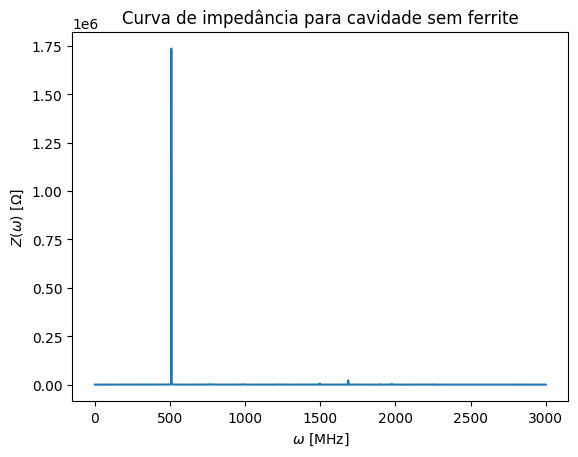

In [32]:
plt.plot(frq, curva)
plt.title("Curva de impedância para cavidade sem ferrite")
plt.xlabel(r"$\omega $ [MHz]")
plt.ylabel(r"$Z(\omega) $ [$\Omega$]")

plt.show()

In [68]:
plt.close("all")

SyntaxError: expected ':' (810060329.py, line 1)